In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
pcos=pd.read_excel('/content/drive/MyDrive/DL_Project_Code/Clinical/PCOS_data_2.xlsx')

In [ ]:
pcos.shape

(541, 45)

In [ ]:
pcos.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.3,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.9,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.3,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.7,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.1,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [ ]:
pcos.isnull().sum()

,0
Sl. No,0
Patient File No.,0
PCOS (Y/N),0
Age (yrs),0
Weight (Kg),0
Height(Cm),0
BMI,0
Blood Group,0
Pulse rate(bpm),0
RR (breaths/min),0


In [ ]:
pcos['Marraige Status (Yrs)'].fillna(pcos['Marraige Status (Yrs)'].mode()[0],inplace=True)
pcos['Fast food (Y/N)'].fillna(pcos['Fast food (Y/N)'].mode()[0],inplace=True)

/tmp/ipykernel_4948/3144708634.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  pcos['Marraige Status (Yrs)'].fillna(pcos['Marraige Status (Yrs)'].mode()[0],inplace=True)
/tmp/ipykernel_4948/3144708634.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing '

In [ ]:
pcos.isnull().sum()

,0
Sl. No,0
Patient File No.,0
PCOS (Y/N),0
Age (yrs),0
Weight (Kg),0
Height(Cm),0
BMI,0
Blood Group,0
Pulse rate(bpm),0
RR (breaths/min),0


In [ ]:
X=pcos.drop(['PCOS (Y/N)','Unnamed: 44'],axis=1)
y=pcos['PCOS (Y/N)']

In [ ]:
pcos['AMH(ng/mL)'] = pd.to_numeric(pcos['AMH(ng/mL)'], errors='coerce')
pcos['II    beta-HCG(mIU/mL)'] = pd.to_numeric(pcos['II    beta-HCG(mIU/mL)'], errors='coerce')

In [ ]:
pcos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3   Age (yrs)               541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   541 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=1)

In [ ]:
print("X_train samples:", len(X_train))
print("X_test samples:", len(X_test))
print("y_train samples:", len(y_train))
print("y_test samples:", len(y_test))

X_train samples: 432
X_test samples: 109
y_train samples: 432
y_test samples: 109


**Logisitc regression**
---

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=10000)
logreg.fit(X_train_scaled, y_train)

y_pred_logreg = logreg.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_logreg))
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("Precision:", precision_score(y_test, y_pred_logreg))
print("Recall:", recall_score(y_test, y_pred_logreg))
print("F1:", f1_score(y_test, y_pred_logreg))

[[68  4]
 [ 8 29]]
Accuracy: 0.8899082568807339
Precision: 0.8787878787878788
Recall: 0.7837837837837838
F1: 0.8285714285714286


**KNN**
---

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_acc = 0
best_k = 0

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', weights='distance')
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    if acc > best_acc:
        best_acc = acc
        best_k = k

print("Best k:", best_k)
print("Best accuracy:", best_acc)

knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', weights='distance')
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_knn))
print('Accuracy:', accuracy_score(y_test, y_pred_knn))
print('Precision:', precision_score(y_test, y_pred_knn))
print('Recall:', recall_score(y_test, y_pred_knn))
print('F1 score:', f1_score(y_test, y_pred_knn))

Best k: 18
Best accuracy: 0.8899082568807339
[[70  2]
 [10 27]]
Accuracy: 0.8899082568807339
Precision: 0.9310344827586207
Recall: 0.7297297297297297
F1 score: 0.8181818181818182


**Naive Bayes**
---

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

nb = GaussianNB(var_smoothing=1e-2)
nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_nb))
print(f'Accuracy: {accuracy_score(y_test, y_pred_nb)}')
print(classification_report(y_test, y_pred_nb))

[[60 12]
 [ 8 29]]
Accuracy: 0.8165137614678899
              precision    recall  f1-score   support

           0       0.88      0.83      0.86        72
           1       0.71      0.78      0.74        37

    accuracy                           0.82       109
   macro avg       0.79      0.81      0.80       109
weighted avg       0.82      0.82      0.82       109



**SVM**
---

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = svm.SVC(kernel='rbf', C=1, gamma='scale')
clf.fit(X_train_scaled, y_train)

y_pred_svm = clf.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_svm))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

[[69  3]
 [ 9 28]]
Accuracy: 0.8899082568807339
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        72
           1       0.90      0.76      0.82        37

    accuracy                           0.89       109
   macro avg       0.89      0.86      0.87       109
weighted avg       0.89      0.89      0.89       109



**Decision Tree - Gini index**
---

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier()
dtree.fit(X_train,y_train)
y_pred_dtree=dtree.predict(X_test)
print(confusion_matrix(y_test,y_pred_dtree))
print('Accuracy:',accuracy_score(y_test,y_pred_dtree))
print('Precision:',precision_score(y_test,y_pred_dtree))
print('Recall:',recall_score(y_test,y_pred_dtree))
print('F1:',f1_score(y_test,y_pred_dtree))

[[68  4]
 [ 8 29]]
Accuracy: 0.8899082568807339
Precision: 0.8787878787878788
Recall: 0.7837837837837838
F1: 0.8285714285714286


**Decision Tree - Entropy**
---

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(criterion='entropy')
dtree.fit(X_train,y_train)
y_pred_dt=dtree.predict(X_test)
print(confusion_matrix(y_test,y_pred_dt))
print('Accuracy:',accuracy_score(y_test,y_pred_dt))
print('Precision:',precision_score(y_test,y_pred_dt))
print('Recall:',recall_score(y_test,y_pred_dt))
print('F1:',f1_score(y_test,y_pred_dt))

[[68  4]
 [10 27]]
Accuracy: 0.8715596330275229
Precision: 0.8709677419354839
Recall: 0.7297297297297297
F1: 0.7941176470588235


**Random forest**
---

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report
rf_clf=RandomForestClassifier(n_estimators=10)
rf_clf.fit(X_train,y_train)
y_pred_rf=rf_clf.predict(X_test)
print(confusion_matrix(y_test,y_pred_rf))
print('Accuracy:',accuracy_score(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))

[[70  2]
 [10 27]]
Accuracy: 0.8899082568807339
              precision    recall  f1-score   support

           0       0.88      0.97      0.92        72
           1       0.93      0.73      0.82        37

    accuracy                           0.89       109
   macro avg       0.90      0.85      0.87       109
weighted avg       0.89      0.89      0.89       109



**LGB - Light Gradient Boost**
---

In [ ]:
!pip install lightgbm

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import re

def sanitize_columns(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = re.sub(r'[^a-zA-Z0-9_]', '', col)
        new_col = new_col.replace(' ', '_')
        new_cols.append(new_col)
    df.columns = new_cols
    return df

X_train_lgbm = X_train.copy()
X_test_lgbm = X_test.copy()

X_train_lgbm = sanitize_columns(X_train_lgbm)
X_test_lgbm = sanitize_columns(X_test_lgbm)

lgbm = LGBMClassifier(
    device='gpu',
    learning_rate=0.1,
    verbosity=-1
)

lgbm.fit(X_train_lgbm, y_train)

y_pred_lgbm = lgbm.predict(X_test_lgbm)

print(confusion_matrix(y_test, y_pred_lgbm))
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))

[[69  3]
 [ 9 28]]
Accuracy: 0.8899082568807339
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        72
           1       0.90      0.76      0.82        37

    accuracy                           0.89       109
   macro avg       0.89      0.86      0.87       109
weighted avg       0.89      0.89      0.89       109



**AdaBoost**
---

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report
abc=AdaBoostClassifier()
abc.fit(X_train,y_train)
y_pred_abc=abc.predict(X_test)
print(confusion_matrix(y_test,y_pred_abc))
print('Accuracy:',accuracy_score(y_test,y_pred_abc))
print(classification_report(y_test,y_pred_abc))

[[69  3]
 [ 7 30]]
Accuracy: 0.908256880733945
              precision    recall  f1-score   support

           0       0.91      0.96      0.93        72
           1       0.91      0.81      0.86        37

    accuracy                           0.91       109
   macro avg       0.91      0.88      0.89       109
weighted avg       0.91      0.91      0.91       109



**CatBoost - Categorical Boosting**
---

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.2 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

model1 = CatBoostClassifier(
    iterations=800,
    learning_rate=0.05,
    depth=4,
    l2_leaf_reg=5,
    random_seed=1,
    eval_metric='Accuracy',
    use_best_model=True,
    od_type='Iter',
    od_wait=40,
    verbose=False
)

model1.fit(X_train, y_train, eval_set=(X_test, y_test))

y_pred_cat = model1.predict(X_test)

print(confusion_matrix(y_test, y_pred_cat))
print(f'Accuracy: {accuracy_score(y_test, y_pred_cat)}')
print(classification_report(y_test, y_pred_cat))

[[70  2]
 [ 7 30]]
Accuracy: 0.9174311926605505
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        72
           1       0.94      0.81      0.87        37

    accuracy                           0.92       109
   macro avg       0.92      0.89      0.90       109
weighted avg       0.92      0.92      0.92       109



In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, f1_score

acc_logreg = accuracy_score(y_test, y_pred_logreg)*100
prec_logreg = precision_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)
recall_logreg = recall_score(y_test, y_pred_logreg)

acc_knn = accuracy_score(y_test, y_pred_knn)*100
prec_knn = precision_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)

acc_nb = accuracy_score(y_test, y_pred_nb)*100
prec_nb = precision_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)

acc_svm = accuracy_score(y_test, y_pred_svm)*100
prec_svm = precision_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)

acc_lgbm = accuracy_score(y_test, y_pred_lgbm)*100
prec_lgbm = precision_score(y_test, y_pred_lgbm)
f1_lgbm = f1_score(y_test, y_pred_lgbm)
recall_lgbm = recall_score(y_test, y_pred_lgbm)

acc_ada = accuracy_score(y_test, y_pred_abc)*100
prec_ada = precision_score(y_test, y_pred_abc)
f1_ada = f1_score(y_test, y_pred_abc)
recall_ada = recall_score(y_test, y_pred_abc)

acc_cat = accuracy_score(y_test, y_pred_cat)*100
prec_cat = precision_score(y_test, y_pred_cat)
f1_cat = f1_score(y_test, y_pred_cat)
recall_cat = recall_score(y_test, y_pred_cat)

acc_rf = accuracy_score(y_test, y_pred_rf)*100
prec_rf = precision_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)

results = [
    ["Logistic Regression", acc_logreg, prec_logreg, recall_logreg, f1_logreg],
    ["Random Forest", acc_rf, prec_rf, recall_rf, f1_rf],
    ["KNN", acc_knn, prec_knn, recall_knn, f1_knn],
    ["Naive Bayes", acc_nb, prec_nb, recall_nb, f1_nb],
    ["SVM", acc_svm, prec_svm, recall_svm, f1_svm],
    ["LGB", acc_lgbm, prec_lgbm, recall_lgbm, f1_lgbm],
    ["AdaBoost", acc_ada, prec_ada, recall_ada, f1_ada],
    ["CatBoost", acc_cat, prec_cat, recall_cat, f1_cat]
]

df_results = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])
df_results = df_results.round(4)

display(df_results)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,88.9908,0.8788,0.7838,0.8286
1,Random Forest,88.9908,0.9310,0.7297,0.8182
2,KNN,88.9908,0.9310,0.7297,0.8182
3,Naive Bayes,81.6514,0.7073,0.7838,0.7436
4,SVM,88.9908,0.9032,0.7568,0.8235
5,LGB,88.9908,0.9032,0.7568,0.8235
6,AdaBoost,90.8257,0.9091,0.8108,0.8571
7,CatBoost,91.7431,0.9375,0.8108,0.8696


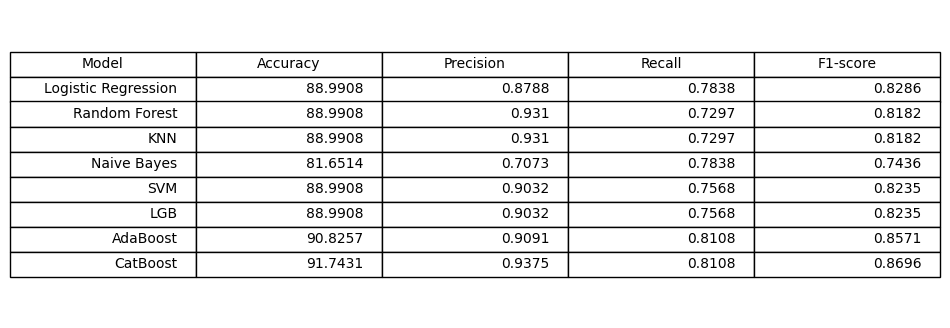

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table = ax.table(
    cellText=df_results.values,
    colLabels=df_results.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.show()

**Ensemble Learning**
---

In [ ]:
from sklearn.ensemble import RandomForestClassifier
X = np.array([y_pred_logreg,y_pred_svm,y_pred_dtree,y_pred_dt,y_pred_rf]).T
meta_learner = RandomForestClassifier()
meta_learner.fit(X,y_test)
en_pred=meta_learner.predict(X)
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score
print(confusion_matrix(y_test,en_pred))
print(accuracy_score(y_test,en_pred))
print(classification_report(y_test,en_pred))

[[72  0]
 [ 6 31]]
0.944954128440367
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        72
           1       1.00      0.84      0.91        37

    accuracy                           0.94       109
   macro avg       0.96      0.92      0.94       109
weighted avg       0.95      0.94      0.94       109



In [ ]:
from sklearn.ensemble import RandomForestClassifier
X = np.array([y_pred_logreg,y_pred_svm,y_pred_dtree,y_pred_dt,y_pred_rf,y_pred_abc,y_pred_cat]).T
meta_learner = RandomForestClassifier()
meta_learner.fit(X,y_test)
en_pred=meta_learner.predict(X)
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score
print(confusion_matrix(y_test,en_pred))
print(accuracy_score(y_test,en_pred))
print(classification_report(y_test,en_pred))

[[72  0]
 [ 5 32]]
0.9541284403669725
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        72
           1       1.00      0.86      0.93        37

    accuracy                           0.95       109
   macro avg       0.97      0.93      0.95       109
weighted avg       0.96      0.95      0.95       109



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np

X = np.array([y_pred_logreg, y_pred_abc, y_pred_cat]).T

meta_learner = RandomForestClassifier()
meta_learner.fit(X, y_test)

en_pred = meta_learner.predict(X)

print("=== Model: Ensemble (Logistic Regression, CatBoost and AdaBoost) ===\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, en_pred))

print("\nAccuracy:")
print(f"{accuracy_score(y_test, en_pred)}")

print("\nClassification Report:")
print(classification_report(y_test, en_pred))

=== Model: Ensemble (Logistic Regression, CatBoost and AdaBoost) ===

Confusion Matrix:
[[70  2]
 [ 7 30]]

Accuracy:
0.9174311926605505

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        72
           1       0.94      0.81      0.87        37

    accuracy                           0.92       109
   macro avg       0.92      0.89      0.90       109
weighted avg       0.92      0.92      0.92       109



In [ ]:
acc_en = accuracy_score(y_test, en_pred)*100
prec_en = precision_score(y_test, en_pred)
recall_en = recall_score(y_test, en_pred)
f1_en = f1_score(y_test, en_pred)

results_2 = [
    ["Ensemble(LR, CatBoost and AdaBoost)", acc_en, prec_en, recall_en, f1_en]]
df_results_2 = pd.DataFrame(results_2, columns=["Model", "Accuracy", "Precision", "Recall","F1-score"])
df_results_2 = df_results_2.round(4)

display(df_results_2)

,Model,Accuracy,Precision,Recall,F1-score
0,"Ensemble(LR, CatBoost and AdaBoost)",91.7431,0.9375,0.8108,0.8696


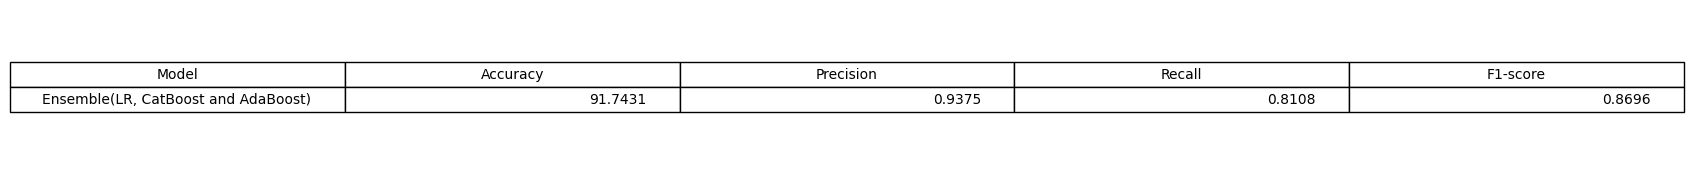

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 2))
ax.axis('off')

table_2 = ax.table(
    cellText=df_results_2.values,
    colLabels=df_results_2.columns,
    loc='center'
)

table_2.auto_set_font_size(False)
table_2.set_fontsize(10)
table_2.scale(1.2, 1.5)

plt.show()

In [ ]:
# ============================
# 1. MOUNT GOOGLE DRIVE
# ============================
from google.colab import drive
drive.mount('/content/drive')

# ============================
# 2. IMPORTS
# ============================
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import xgboost as xgb

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Install only if needed
# !pip install lightgbm
# !pip install catboost

# ============================
# 3. LOAD DATA
# ============================
FILE_PATH = '/content/drive/MyDrive/DL_Project_Code/Clinical/PCOS_data_2.xlsx'
TARGET_COL = 'PCOS (Y/N)'
DROP_COLS = ['Unnamed: 44']

pcos = pd.read_excel(FILE_PATH)

print("Original shape:", pcos.shape)
display(pcos.head())
print("\nMissing values before cleaning:\n")
print(pcos.isnull().sum())

# ============================
# 4. BASIC CLEANING
# ============================
# Fill specific columns like your original file
if 'Marraige Status (Yrs)' in pcos.columns:
    pcos['Marraige Status (Yrs)'].fillna(
        pcos['Marraige Status (Yrs)'].mode()[0], inplace=True
    )

if 'Fast food (Y/N)' in pcos.columns:
    pcos['Fast food (Y/N)'].fillna(
        pcos['Fast food (Y/N)'].mode()[0], inplace=True
    )

# Convert all non-target columns to numeric BEFORE creating X
for col in pcos.columns:
    if col != TARGET_COL:
        pcos[col] = pd.to_numeric(pcos[col], errors='coerce')

# Ensure target is numeric too
pcos[TARGET_COL] = pd.to_numeric(pcos[TARGET_COL], errors='coerce')

# Drop rows where target is missing
pcos = pcos.dropna(subset=[TARGET_COL]).reset_index(drop=True)

print("\nMissing values after partial cleaning:\n")
print(pcos.isnull().sum())

print("\nData info:\n")
print(pcos.info())

# ============================
# 5. CREATE X AND y
# ============================
drop_existing = [c for c in DROP_COLS if c in pcos.columns]
X = pcos.drop(columns=[TARGET_COL] + drop_existing)
y = pcos[TARGET_COL].astype(int)

print("\nNumber of features used:", X.shape[1])
print("Feature names:")
print(list(X.columns))

# ============================
# 6. TRAIN / TEST SPLIT
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=1,
    stratify=y
)

print("\nSplit sizes:")
print("X_train samples:", len(X_train))
print("X_test samples:", len(X_test))
print("y_train samples:", len(y_train))
print("y_test samples:", len(y_test))

# ============================
# 7. IMPUTATION
# ============================
# Match the newer baseline: median imputation on ALL features
imputer = SimpleImputer(strategy='median')

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# ============================
# 8. HELPERS
# ============================
def print_model_results(model_name, y_true, y_pred):
    print(f"\n=== Model: {model_name} ===\n")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nAccuracy:")
    print(accuracy_score(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred) * 100,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0)
    }

def sanitize_columns(df):
    df = df.copy()
    new_cols = []
    for col in df.columns:
        new_col = re.sub(r'[^a-zA-Z0-9_]', '', str(col))
        new_col = new_col.replace(' ', '_')
        new_cols.append(new_col)
    df.columns = new_cols
    return df

results = []

# ============================
# 9. LOGISTIC REGRESSION
# ============================
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=10000, random_state=1)
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)

print_model_results("Logistic Regression", y_test, y_pred_logreg)
m = get_metrics(y_test, y_pred_logreg)
results.append(["Logistic Regression", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

# ============================
# 10. KNN
# ============================
from sklearn.neighbors import KNeighborsClassifier

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_acc = -1
best_k = 1

for k in range(1, 21):
    knn_temp = KNeighborsClassifier(
        n_neighbors=k,
        metric='euclidean',
        weights='distance'
    )
    knn_temp.fit(X_train_scaled, y_train)
    y_pred_temp = knn_temp.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_temp)

    if acc > best_acc:
        best_acc = acc
        best_k = k

print("\nBest k:", best_k)
print("Best accuracy:", best_acc)

knn = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='euclidean',
    weights='distance'
)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print_model_results(f"KNN (k={best_k})", y_test, y_pred_knn)
m = get_metrics(y_test, y_pred_knn)
results.append([f"KNN (k={best_k})", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

# ============================
# 11. NAIVE BAYES
# ============================
from sklearn.naive_bayes import GaussianNB

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

nb = GaussianNB(var_smoothing=1e-2)
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)

print_model_results("Naive Bayes", y_test, y_pred_nb)
m = get_metrics(y_test, y_pred_nb)
results.append(["Naive Bayes", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

# ============================
# 12. SVM
# ============================
from sklearn import svm

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = svm.SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=1)
clf.fit(X_train_scaled, y_train)
y_pred_svm = clf.predict(X_test_scaled)

print_model_results("SVM", y_test, y_pred_svm)
m = get_metrics(y_test, y_pred_svm)
results.append(["SVM", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

# ============================
# 13. DECISION TREE - GINI
# ============================
dtree_gini = DecisionTreeClassifier(random_state=1)
dtree_gini.fit(X_train, y_train)
y_pred_dtree = dtree_gini.predict(X_test)

print_model_results("Decision Tree (Gini)", y_test, y_pred_dtree)
m = get_metrics(y_test, y_pred_dtree)
results.append(["Decision Tree (Gini)", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

# ============================
# 14. DECISION TREE - ENTROPY
# ============================
dtree_entropy = DecisionTreeClassifier(criterion='entropy', random_state=1)
dtree_entropy.fit(X_train, y_train)
y_pred_dt = dtree_entropy.predict(X_test)

print_model_results("Decision Tree (Entropy)", y_test, y_pred_dt)
m = get_metrics(y_test, y_pred_dt)
results.append(["Decision Tree (Entropy)", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

# ============================
# 15. RANDOM FOREST
# ============================
rf_clf = RandomForestClassifier(n_estimators=100, random_state=1)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print_model_results("Random Forest", y_test, y_pred_rf)
m = get_metrics(y_test, y_pred_rf)
results.append(["Random Forest", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

# ============================
# 16. LIGHTGBM
# ============================
X_train_lgbm = sanitize_columns(X_train)
X_test_lgbm = sanitize_columns(X_test)

lgbm = LGBMClassifier(
    learning_rate=0.1,
    verbosity=-1,
    random_state=1
)

lgbm.fit(X_train_lgbm, y_train)
y_pred_lgbm = lgbm.predict(X_test_lgbm)

print_model_results("LightGBM", y_test, y_pred_lgbm)
m = get_metrics(y_test, y_pred_lgbm)
results.append(["LGB", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

# ============================
# 17. ADABOOST
# ============================
abc = AdaBoostClassifier(random_state=1)
abc.fit(X_train, y_train)
y_pred_abc = abc.predict(X_test)

print_model_results("AdaBoost", y_test, y_pred_abc)
m = get_metrics(y_test, y_pred_abc)
results.append(["AdaBoost", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

# ============================
# 18. CATBOOST
# ============================
model1 = CatBoostClassifier(
    iterations=800,
    learning_rate=0.05,
    depth=4,
    l2_leaf_reg=5,
    random_seed=1,
    eval_metric='Accuracy',
    use_best_model=True,
    od_type='Iter',
    od_wait=40,
    verbose=False
)

model1.fit(X_train, y_train, eval_set=(X_test, y_test))
y_pred_cat = model1.predict(X_test)
y_pred_cat = np.array(y_pred_cat).astype(int).reshape(-1)

print_model_results("CatBoost", y_test, y_pred_cat)
m = get_metrics(y_test, y_pred_cat)
results.append(["CatBoost", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

# ============================
# 19. XGBOOST
# ============================
xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    eval_metric='logloss',
    random_state=1
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print_model_results("XGBoost", y_test, y_pred_xgb)
m = get_metrics(y_test, y_pred_xgb)
results.append(["XGBoost", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])

# ============================
# 20. RESULTS TABLE
# ============================
df_results = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"]
)
df_results = df_results.round(4)

print("\nFinal Results Table:\n")
display(df_results)

# ============================
# 21. TABLE PLOT
# ============================
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')

table = ax.table(
    cellText=df_results.values,
    colLabels=df_results.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.show()

In [2]:
!pip install lightgbm
!pip install catboost
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [3]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import xgboost as xgb

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [4]:

FILE_PATH = '/content/drive/MyDrive/DL_Project_Code/Clinical/PCOS_data_2.xlsx'
TARGET_COL = 'PCOS (Y/N)'
DROP_COLS = ['Unnamed: 44']

pcos = pd.read_excel(FILE_PATH)

print("Original shape:", pcos.shape)
display(pcos.head())

print("\nMissing values before cleaning:\n")
print(pcos.isnull().sum())

Original shape: (541, 45)


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.3,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.9,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.3,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.7,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.1,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN



Missing values before cleaning:

Sl. No                      0
Patient File No.            0
PCOS (Y/N)                  0
Age (yrs)                   0
Weight (Kg)                 0
Height(Cm)                  0
BMI                         0
Blood Group                 0
Pulse rate(bpm)             0
RR (breaths/min)            0
Hb(g/dl)                    0
Cycle(R/I)                  0
Cycle length(days)          0
Marraige Status (Yrs)       1
Pregnant(Y/N)               0
No. of abortions            0
I   beta-HCG(mIU/mL)        0
II    beta-HCG(mIU/mL)      0
FSH(mIU/mL)                 0
LH(mIU/mL)                  0
FSH/LH                      0
Hip(inch)                   0
Waist(inch)                 0
Waist:Hip Ratio             0
TSH (mIU/L)                 0
AMH(ng/mL)                  0
PRL(ng/mL)                  0
Vit D3 (ng/mL)              0
PRG(ng/mL)                  0
RBS(mg/dl)                  0
Weight gain(Y/N)            0
hair growth(Y/N)            0
Skin d

In [5]:
if 'Marraige Status (Yrs)' in pcos.columns:
    pcos['Marraige Status (Yrs)'].fillna(
        pcos['Marraige Status (Yrs)'].mode()[0],
        inplace=True
    )

if 'Fast food (Y/N)' in pcos.columns:
    pcos['Fast food (Y/N)'].fillna(
        pcos['Fast food (Y/N)'].mode()[0],
        inplace=True
    )

# Convert all non-target columns to numeric BEFORE creating X
for col in pcos.columns:
    if col != TARGET_COL:
        pcos[col] = pd.to_numeric(pcos[col], errors='coerce')

# Ensure target is numeric too
pcos[TARGET_COL] = pd.to_numeric(pcos[TARGET_COL], errors='coerce')

# Drop rows with missing target
pcos = pcos.dropna(subset=[TARGET_COL]).reset_index(drop=True)

print("\nMissing values after partial cleaning:\n")
print(pcos.isnull().sum())

print("\nData info:\n")
print(pcos.info())


Missing values after partial cleaning:

Sl. No                      0
Patient File No.            0
PCOS (Y/N)                  0
Age (yrs)                   0
Weight (Kg)                 0
Height(Cm)                  0
BMI                         0
Blood Group                 0
Pulse rate(bpm)             0
RR (breaths/min)            0
Hb(g/dl)                    0
Cycle(R/I)                  0
Cycle length(days)          0
Marraige Status (Yrs)       0
Pregnant(Y/N)               0
No. of abortions            0
I   beta-HCG(mIU/mL)        0
II    beta-HCG(mIU/mL)      0
FSH(mIU/mL)                 0
LH(mIU/mL)                  0
FSH/LH                      0
Hip(inch)                   0
Waist(inch)                 0
Waist:Hip Ratio             0
TSH (mIU/L)                 0
AMH(ng/mL)                  0
PRL(ng/mL)                  0
Vit D3 (ng/mL)              0
PRG(ng/mL)                  0
RBS(mg/dl)                  0
Weight gain(Y/N)            0
hair growth(Y/N)            0

In [6]:
drop_existing = [c for c in DROP_COLS if c in pcos.columns]

X = pcos.drop(columns=[TARGET_COL] + drop_existing)
y = pcos[TARGET_COL].astype(int)

print("\nNumber of features used:", X.shape[1])
print("Feature names:")
print(list(X.columns))


Number of features used: 43
Feature names:
['Sl. No', 'Patient File No.', 'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI', 'Blood Group', 'Pulse rate(bpm)', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of abortions', 'I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)']


In [7]:
# ============================
# 7. TRAIN / TEST SPLIT
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=1,
    stratify=y
)

print("\nSplit sizes:")
print("X_train samples:", len(X_train))
print("X_test samples:", len(X_test))
print("y_train samples:", len(y_train))
print("y_test samples:", len(y_test))


Split sizes:
X_train samples: 432
X_test samples: 109
y_train samples: 432
y_test samples: 109


In [8]:

# ============================
# 8. IMPUTATION
# ============================
imputer = SimpleImputer(strategy='median')

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [9]:
# ============================
# 9. HELPERS
# ============================
def print_model_results(model_name, y_true, y_pred):
    print(f"\n=== Model: {model_name} ===\n")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nAccuracy:")
    print(accuracy_score(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred) * 100,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0)
    }

def sanitize_columns(df):
    df = df.copy()
    new_cols = []
    for col in df.columns:
        new_col = re.sub(r'[^a-zA-Z0-9_]', '', str(col))
        new_col = new_col.replace(' ', '_')
        new_cols.append(new_col)
    df.columns = new_cols
    return df

results = []

In [10]:
# ============================
# 10. SCALED DATA FOR MODELS THAT NEED IT
# ============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

LOGISTIC REGRESSION
---

In [11]:

logreg = LogisticRegression(max_iter=10000, random_state=1)
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)

print_model_results("Logistic Regression", y_test, y_pred_logreg)
m = get_metrics(y_test, y_pred_logreg)
results.append(["Logistic Regression", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])


=== Model: Logistic Regression ===

Confusion Matrix:
[[68  5]
 [ 2 34]]

Accuracy:
0.9357798165137615

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        73
           1       0.87      0.94      0.91        36

    accuracy                           0.94       109
   macro avg       0.92      0.94      0.93       109
weighted avg       0.94      0.94      0.94       109



In [12]:
# ============================
# 12. KNN
# ============================
best_acc = -1
best_k = 1

for k in range(1, 21):
    knn_temp = KNeighborsClassifier(
        n_neighbors=k,
        metric='euclidean',
        weights='distance'
    )
    knn_temp.fit(X_train_scaled, y_train)
    y_pred_temp = knn_temp.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_temp)

    if acc > best_acc:
        best_acc = acc
        best_k = k

print("\nBest k:", best_k)
print("Best accuracy:", best_acc)

knn = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='euclidean',
    weights='distance'
)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print_model_results(f"KNN (k={best_k})", y_test, y_pred_knn)
m = get_metrics(y_test, y_pred_knn)
results.append([f"KNN (k={best_k})", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])


Best k: 10
Best accuracy: 0.8990825688073395

=== Model: KNN (k=10) ===

Confusion Matrix:
[[72  1]
 [10 26]]

Accuracy:
0.8990825688073395

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93        73
           1       0.96      0.72      0.83        36

    accuracy                           0.90       109
   macro avg       0.92      0.85      0.88       109
weighted avg       0.91      0.90      0.89       109



In [13]:
# ============================
# 13. NAIVE BAYES
# ============================
nb = GaussianNB(var_smoothing=1e-2)
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)

print_model_results("Naive Bayes", y_test, y_pred_nb)
m = get_metrics(y_test, y_pred_nb)
results.append(["Naive Bayes", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])


=== Model: Naive Bayes ===

Confusion Matrix:
[[64  9]
 [ 4 32]]

Accuracy:
0.8807339449541285

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91        73
           1       0.78      0.89      0.83        36

    accuracy                           0.88       109
   macro avg       0.86      0.88      0.87       109
weighted avg       0.89      0.88      0.88       109



In [14]:
# ============================
# 14. SVM
# ============================
svm_model = svm.SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=1)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

print_model_results("SVM", y_test, y_pred_svm)
m = get_metrics(y_test, y_pred_svm)
results.append(["SVM", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])


=== Model: SVM ===

Confusion Matrix:
[[70  3]
 [ 6 30]]

Accuracy:
0.9174311926605505

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        73
           1       0.91      0.83      0.87        36

    accuracy                           0.92       109
   macro avg       0.92      0.90      0.90       109
weighted avg       0.92      0.92      0.92       109



In [15]:
# ============================
# 15. DECISION TREE - GINI
# ============================
dtree_gini = DecisionTreeClassifier(random_state=1)
dtree_gini.fit(X_train, y_train)
y_pred_dtree = dtree_gini.predict(X_test)

print_model_results("Decision Tree (Gini)", y_test, y_pred_dtree)
m = get_metrics(y_test, y_pred_dtree)
results.append(["Decision Tree (Gini)", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])


=== Model: Decision Tree (Gini) ===

Confusion Matrix:
[[65  8]
 [12 24]]

Accuracy:
0.8165137614678899

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87        73
           1       0.75      0.67      0.71        36

    accuracy                           0.82       109
   macro avg       0.80      0.78      0.79       109
weighted avg       0.81      0.82      0.81       109



In [16]:
# ============================
# 16. DECISION TREE - ENTROPY
# ============================
dtree_entropy = DecisionTreeClassifier(criterion='entropy', random_state=1)
dtree_entropy.fit(X_train, y_train)
y_pred_dt = dtree_entropy.predict(X_test)

print_model_results("Decision Tree (Entropy)", y_test, y_pred_dt)
m = get_metrics(y_test, y_pred_dt)
results.append(["Decision Tree (Entropy)", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])


=== Model: Decision Tree (Entropy) ===

Confusion Matrix:
[[64  9]
 [11 25]]

Accuracy:
0.8165137614678899

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86        73
           1       0.74      0.69      0.71        36

    accuracy                           0.82       109
   macro avg       0.79      0.79      0.79       109
weighted avg       0.81      0.82      0.82       109



In [17]:
# ============================
# 17. RANDOM FOREST
# ============================
rf_clf = RandomForestClassifier(n_estimators=100, random_state=1)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print_model_results("Random Forest", y_test, y_pred_rf)
m = get_metrics(y_test, y_pred_rf)
results.append(["Random Forest", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])


=== Model: Random Forest ===

Confusion Matrix:
[[71  2]
 [ 7 29]]

Accuracy:
0.9174311926605505

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        73
           1       0.94      0.81      0.87        36

    accuracy                           0.92       109
   macro avg       0.92      0.89      0.90       109
weighted avg       0.92      0.92      0.92       109



In [18]:
# ============================
# 18. LIGHTGBM
# ============================
X_train_lgbm = sanitize_columns(X_train)
X_test_lgbm = sanitize_columns(X_test)

lgbm = LGBMClassifier(
    learning_rate=0.1,
    verbosity=-1,
    random_state=1
)

lgbm.fit(X_train_lgbm, y_train)
y_pred_lgbm = lgbm.predict(X_test_lgbm)

print_model_results("LightGBM", y_test, y_pred_lgbm)
m = get_metrics(y_test, y_pred_lgbm)
results.append(["LGB", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])


=== Model: LightGBM ===

Confusion Matrix:
[[70  3]
 [ 3 33]]

Accuracy:
0.944954128440367

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        73
           1       0.92      0.92      0.92        36

    accuracy                           0.94       109
   macro avg       0.94      0.94      0.94       109
weighted avg       0.94      0.94      0.94       109



In [19]:
# ============================
# 19. ADABOOST
# ============================
abc = AdaBoostClassifier(random_state=1)
abc.fit(X_train, y_train)
y_pred_abc = abc.predict(X_test)

print_model_results("AdaBoost", y_test, y_pred_abc)
m = get_metrics(y_test, y_pred_abc)
results.append(["AdaBoost", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])


=== Model: AdaBoost ===

Confusion Matrix:
[[71  2]
 [ 5 31]]

Accuracy:
0.9357798165137615

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        73
           1       0.94      0.86      0.90        36

    accuracy                           0.94       109
   macro avg       0.94      0.92      0.93       109
weighted avg       0.94      0.94      0.94       109



In [20]:
# ============================
# 20. CATBOOST
# ============================
model1 = CatBoostClassifier(
    iterations=800,
    learning_rate=0.05,
    depth=4,
    l2_leaf_reg=5,
    random_seed=1,
    eval_metric='Accuracy',
    use_best_model=True,
    od_type='Iter',
    od_wait=40,
    verbose=False
)

model1.fit(X_train, y_train, eval_set=(X_test, y_test))
y_pred_cat = model1.predict(X_test)
y_pred_cat = np.array(y_pred_cat).astype(int).reshape(-1)

print_model_results("CatBoost", y_test, y_pred_cat)
m = get_metrics(y_test, y_pred_cat)
results.append(["CatBoost", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])


=== Model: CatBoost ===

Confusion Matrix:
[[71  2]
 [ 3 33]]

Accuracy:
0.9541284403669725

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97        73
           1       0.94      0.92      0.93        36

    accuracy                           0.95       109
   macro avg       0.95      0.94      0.95       109
weighted avg       0.95      0.95      0.95       109



In [21]:
# ============================
# 21. XGBOOST
# ============================
xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    eval_metric='logloss',
    random_state=1
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print_model_results("XGBoost", y_test, y_pred_xgb)
m = get_metrics(y_test, y_pred_xgb)
results.append(["XGBoost", m["Accuracy"], m["Precision"], m["Recall"], m["F1-score"]])


=== Model: XGBoost ===

Confusion Matrix:
[[71  2]
 [ 4 32]]

Accuracy:
0.944954128440367

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        73
           1       0.94      0.89      0.91        36

    accuracy                           0.94       109
   macro avg       0.94      0.93      0.94       109
weighted avg       0.94      0.94      0.94       109



In [22]:
# ============================
# 22. BASELINE RESULTS TABLE
# ============================
df_results = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"]
).round(4)

print("\nFinal Baseline Results Table:\n")
display(df_results)


Final Baseline Results Table:



,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,93.5780,0.8718,0.9444,0.9067
1,KNN (k=10),89.9083,0.9630,0.7222,0.8254
2,Naive Bayes,88.0734,0.7805,0.8889,0.8312
3,SVM,91.7431,0.9091,0.8333,0.8696
4,Decision Tree (Gini),81.6514,0.7500,0.6667,0.7059
5,Decision Tree (Entropy),81.6514,0.7353,0.6944,0.7143
6,Random Forest,91.7431,0.9355,0.8056,0.8657
7,LGB,94.4954,0.9167,0.9167,0.9167
8,AdaBoost,93.5780,0.9394,0.8611,0.8986
9,CatBoost,95.4128,0.9429,0.9167,0.9296


In [23]:

# ============================
# 23. CORRECT ENSEMBLE (STACKING)
# ============================
# Split training set into base-train and meta-train
X_base, X_meta, y_base, y_meta = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=1,
    stratify=y_train
)

# Scale for LR/SVM/KNN/NB-type models
stack_scaler = StandardScaler()
X_base_scaled = stack_scaler.fit_transform(X_base)
X_meta_scaled = stack_scaler.transform(X_meta)
X_test_scaled_stack = stack_scaler.transform(X_test)

# -------- Base models for ensemble --------
# Logistic Regression
logreg_base = LogisticRegression(max_iter=10000, random_state=1)
logreg_base.fit(X_base_scaled, y_base)
meta_pred_logreg = logreg_base.predict(X_meta_scaled)
test_pred_logreg = logreg_base.predict(X_test_scaled_stack)

# AdaBoost
ada_base = AdaBoostClassifier(random_state=1)
ada_base.fit(X_base, y_base)
meta_pred_ada = ada_base.predict(X_meta)
test_pred_ada = ada_base.predict(X_test)

# CatBoost
cat_base = CatBoostClassifier(
    iterations=800,
    learning_rate=0.05,
    depth=4,
    l2_leaf_reg=5,
    random_seed=1,
    eval_metric='Accuracy',
    verbose=False
)
cat_base.fit(X_base, y_base)
meta_pred_cat = cat_base.predict(X_meta)
test_pred_cat = cat_base.predict(X_test)

meta_pred_cat = np.array(meta_pred_cat).astype(int).reshape(-1)
test_pred_cat = np.array(test_pred_cat).astype(int).reshape(-1)

# Meta features
X_meta_stack = np.column_stack([
    meta_pred_logreg,
    meta_pred_ada,
    meta_pred_cat
])

X_test_stack = np.column_stack([
    test_pred_logreg,
    test_pred_ada,
    test_pred_cat
])

# Meta learner
meta_learner = RandomForestClassifier(random_state=1)
meta_learner.fit(X_meta_stack, y_meta)

en_pred = meta_learner.predict(X_test_stack)

print("\n=== Model: Ensemble (Logistic Regression, AdaBoost, CatBoost) ===\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, en_pred))

print("\nAccuracy:")
print(accuracy_score(y_test, en_pred))

print("\nClassification Report:")
print(classification_report(y_test, en_pred, zero_division=0))

acc_en = accuracy_score(y_test, en_pred) * 100
prec_en = precision_score(y_test, en_pred, zero_division=0)
recall_en = recall_score(y_test, en_pred, zero_division=0)
f1_en = f1_score(y_test, en_pred, zero_division=0)

df_results_ensemble = pd.DataFrame(
    [["Ensemble (LR, AdaBoost, CatBoost)", acc_en, prec_en, recall_en, f1_en]],
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"]
).round(4)

print("\nEnsemble Results:\n")
display(df_results_ensemble)




=== Model: Ensemble (Logistic Regression, AdaBoost, CatBoost) ===

Confusion Matrix:
[[71  2]
 [ 6 30]]

Accuracy:
0.926605504587156

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95        73
           1       0.94      0.83      0.88        36

    accuracy                           0.93       109
   macro avg       0.93      0.90      0.91       109
weighted avg       0.93      0.93      0.93       109


Ensemble Results:



,Model,Accuracy,Precision,Recall,F1-score
0,"Ensemble (LR, AdaBoost, CatBoost)",92.6606,0.9375,0.8333,0.8824


In [24]:
# ============================
# 24. FINAL RESULTS WITH ENSEMBLE
# ============================
df_results_final = pd.concat([df_results, df_results_ensemble], ignore_index=True).round(4)

print("\nFinal Results Table Including Ensemble:\n")
display(df_results_final)




Final Results Table Including Ensemble:



,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,93.5780,0.8718,0.9444,0.9067
1,KNN (k=10),89.9083,0.9630,0.7222,0.8254
2,Naive Bayes,88.0734,0.7805,0.8889,0.8312
3,SVM,91.7431,0.9091,0.8333,0.8696
4,Decision Tree (Gini),81.6514,0.7500,0.6667,0.7059
5,Decision Tree (Entropy),81.6514,0.7353,0.6944,0.7143
6,Random Forest,91.7431,0.9355,0.8056,0.8657
7,LGB,94.4954,0.9167,0.9167,0.9167
8,AdaBoost,93.5780,0.9394,0.8611,0.8986
9,CatBoost,95.4128,0.9429,0.9167,0.9296


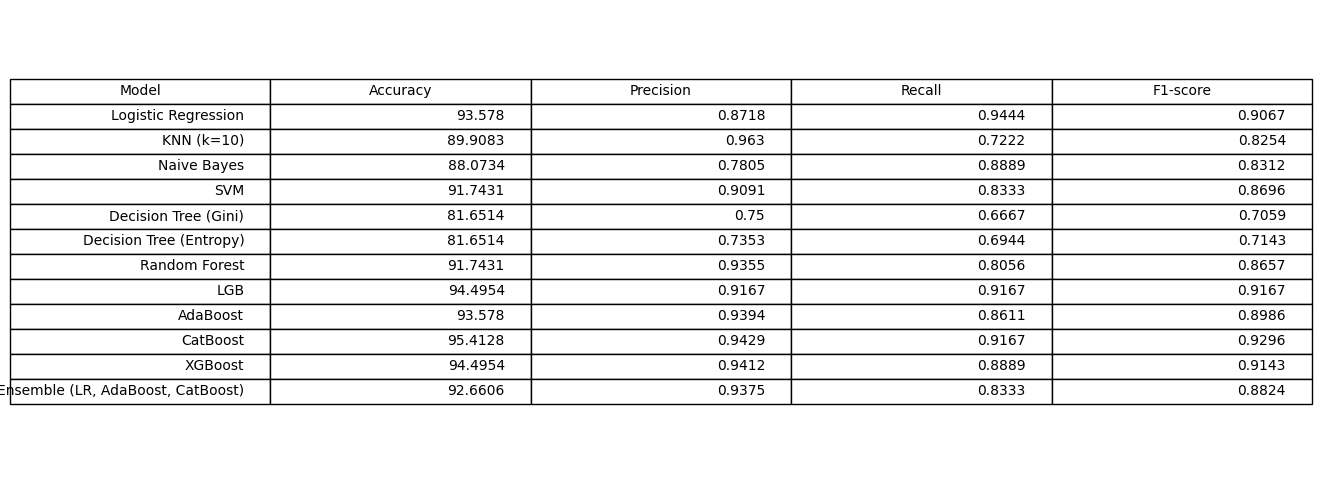

In [25]:
# ============================
# 25. TABLE PLOT
# ============================
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

table = ax.table(
    cellText=df_results_final.values,
    colLabels=df_results_final.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.show()